## Import all neccessary libraries

In [ ]:
'''Import libraries & area weights'''
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cftime
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
from scipy.stats import linregress


'''Import area weights'''
# Import weights for each lat-lon grid point since they have different sizes for different latitudes
# Nan for areas that are land covered, otherwise values proportional to size of the grid points, fully integrated = 1
area_weights = xr.open_mfdataset('area_weights.nc')
area_weights = area_weights['area_t']
# for visualization: area_weights.plot()

## Define functions

In [ ]:
'''Define all the used evaluation functions'''
# Calculate the DJF, MAM, JJA, SON & annual mean time series
def compute_seasonal_averages(ds):
    # Input needs to be xr.DataArray with cftime values on time dimension

    # Rename 'Time' -> 'time' if neccessary
    if 'Time' in ds.coords:
        ds = ds.rename({'Time': 'time'})

    # Compute the seasonal averages
    mam_mean = ds.sel(time=ds['time'].dt.month.isin([3, 4, 5])).groupby('time.year').mean(dim='time')
    jja_mean = ds.sel(time=ds['time'].dt.month.isin([6, 7, 8])).groupby('time.year').mean(dim='time')
    son_mean = ds.sel(time=ds['time'].dt.month.isin([9, 10, 11])).groupby('time.year').mean(dim='time')
    # DJF needs more than one line because the months lay in two calendar years
    djf = ds.sel(time=ds['time'].dt.month.isin([12, 1, 2]))
    djf_mean = djf.assign_coords(year=(djf['time'].dt.year + (djf['time'].dt.month == 12))).groupby('year').mean(dim='time')
    annual_mean = ds.groupby('time.year').mean(dim='time')
    seasonal_means = xr.concat([mam_mean, jja_mean, son_mean, djf_mean, annual_mean], dim="season")
    seasonal_means["season"] = ["MAM", "JJA", "SON", "DJF","Annual"]
    return seasonal_means


#####


# Compute autocorrelation function of a given dataset
def autocorrelation(ds,steps):
    # ds - time series dataarray

    if isinstance(ds, xr.DataArray):
        time_series = ds.values[~np.isnan(ds.values)]  # remove nan values
    else:
        time_series = ds
    
    # At first substract the linear trend from the time series
    time_index = np.arange(0,len(time_series),1)
    slope, intercept, _, _, _ = linregress(time_index, time_series)
    trend = slope * time_index + intercept
    time_series = time_series - trend

    autocorr = []
    for i in range (1,int(steps)+1):
        autocorr = np.append(autocorr, np.corrcoef(time_series[:-i], time_series[i:])[0, 1])
    return autocorr


#####

 
# Basic 2x2 plot of salt&temp seasonal time series in the top and their autocorrelation function in the bottom row
def basicplot_SEASONAL_temp_and_salt(ts_temp,ts_salt,ac_temp,ac_salt):

    labels = ['MAM', 'JJA', 'SON', 'DJF', 'Annual']
    linestyles = ['-', '-', '-', '-', '-']
    time_lag = np.arange(1,51)

    fig, ax = plt.subplots(2,2,figsize=(9,6))
    for i in range (5):
        ax[0,0].plot(ts_temp['year'],ts_temp.isel(season=i), label=labels[i], linestyle=linestyles[i], linewidth=1)
        ax[0,1].plot(ts_salt['year'],ts_salt.isel(season=i), label=labels[i], linestyle=linestyles[i], linewidth=1)
        ax[1,0].plot(time_lag, ac_temp[i], label=labels[i], linestyle=linestyles[i], linewidth=1)
        ax[1,1].plot(time_lag, ac_salt[i], label=labels[i], linestyle=linestyles[i], linewidth=1)
    ax[1,0].set_ylim(-1,1)
    ax[1,1].set_ylim(-1,1)
    ax[1,0].set_ylabel('Autocorrelation')
    ax[1,1].set_ylabel('Autocorrelation')
    ax[0,0].set_xlabel('Year')
    ax[0,1].set_xlabel('Year')
    ax[1,0].set_xlabel('Time lag [yrs]')
    ax[1,1].set_xlabel('Time lag [yrs]')
    for ax_subplot in fig.axes: # for all subplots
        ax_subplot.grid()
    plt.tight_layout()
    
    return fig, ax

## SST & SSS

In [4]:
'''Read in oceanmonth with temp,salt,h'''
# Read in the annual .nc files containing results of the reference run
ds_oceanmonth = xr.open_mfdataset(
    '../reference_run/reference_run_01_*/*0101.ocean_month.nc',
    combine='nested',  # needed for concat
    concat_dim='time',  # concatenate along time dimension to get one dataset from 1948-2020
    preprocess= lambda ds_oceanmonth:ds_oceanmonth[['temp','salt','h']]  # select wanted data variables to remove unneccessary stuff
)
print(ds_oceanmonth)

<xarray.Dataset> Size: 13GB
Dimensions:  (time: 864, zl: 100, yh: 102, xh: 91)
Coordinates:
  * yh       (yh) float64 816B 53.64 53.76 53.88 54.0 ... 65.4 65.52 65.64 65.76
  * zl       (zl) float64 800B 0.4367 1.323 2.221 3.145 ... 220.7 224.4 228.1
  * time     (time) object 7kB 1948-01-16 12:00:00 ... 2019-12-16 12:00:00
  * xh       (xh) float64 728B 8.12 8.36 8.6 8.84 ... 29.0 29.24 29.48 29.72
Data variables:
    temp     (time, zl, yh, xh) float32 3GB dask.array<chunksize=(12, 100, 102, 91), meta=np.ndarray>
    salt     (time, zl, yh, xh) float32 3GB dask.array<chunksize=(12, 100, 102, 91), meta=np.ndarray>
    h        (time, zl, yh, xh) float64 6GB dask.array<chunksize=(12, 100, 102, 91), meta=np.ndarray>
Attributes:
    filename:          19480101.ocean_month.nc
    title:             MOM6
    associated_files:  area_t: 19480101.ocean_static.nc
    grid_type:         regular
    grid_tile:         N/A


In [ ]:
'''Create area weights'''
# ds_oceanstatic = xr.open_mfdataset(
#     '../reference_run/reference_run_01_*/*0101.ocean_static.nc',
#     combine='nested',  # needed for concat
#     concat_dim='time',  # concatenate along time dimension to get one dataset from 1948-2020
#     preprocess= lambda ds_oceanstatic:ds_oceanstatic[['area_t','depth_ocean']]  # select wanted data variables to remove unneccessary stuff
# )
# print(ds_oceanstatic)

# # Compute the weights of each grid point ~ the relative area of each grid point, to perform proper weighed averages
# area_weights = xr.DataArray(ds_oceanstatic.isel(time=0)['area_t'] / (ds_oceanstatic.isel(time=0)['area_t'].sum().compute().values))
# area_weights = area_weights.where(ds_oceanmonth.isel(zl=0,time=0)['temp'].notnull())
# area_weights = area_weights.squeeze().drop_vars(['zl', 'time'])
# area_weights = area_weights / area_weights.sum()  # area_t for some reasons contains values some grid points over land. these have to be excluded
# area_weights.to_netcdf("area_weights.nc")
# #plt.pcolormesh(area_weights.xh, area_weights.yh, ds_oceanstatic.isel(time=0)['depth_ocean'].values)
# #plt.colorbar()
# # with normal .mean() it's on average 0.13°C colder

<xarray.Dataset> Size: 5MB
Dimensions:      (time: 72, yh: 102, xh: 91)
Coordinates:
  * xh           (xh) float64 728B 8.12 8.36 8.6 8.84 ... 29.0 29.24 29.48 29.72
  * yh           (yh) float64 816B 53.64 53.76 53.88 54.0 ... 65.52 65.64 65.76
Dimensions without coordinates: time
Data variables:
    area_t       (time, yh, xh) float32 3MB dask.array<chunksize=(1, 102, 91), meta=np.ndarray>
    depth_ocean  (time, yh, xh) float32 3MB dask.array<chunksize=(1, 102, 91), meta=np.ndarray>
Attributes:
    filename:   19480101.ocean_static.nc
    title:      MOM6
    grid_type:  regular
    grid_tile:  N/A


In [6]:
# Select SST & SSS averaged over whole BS
ds_SST = (ds_oceanmonth.isel(zl=0)['temp'] * area_weights).sum(dim=["xh", "yh"])
ds_SSS = (ds_oceanmonth.isel(zl=0)['salt'] * area_weights).sum(dim=["xh", "yh"])

# Compute the seasonal averages with function defined in the beginning
seasonal_SST = compute_seasonal_averages(ds_SST)
seasonal_SSS = compute_seasonal_averages(ds_SSS)

In [7]:
# Compute SST autocorrelation with function defined in the beginning
autocorr_SST = np.zeros([5,50])
for i in range(5):
    autocorr_SST[i,:] = autocorrelation(seasonal_SST.isel(season=i),50)

# Compute SSS autocorrelation with function defined in the beginning
autocorr_SSS = np.zeros([5,50])
for i in range(5):
    autocorr_SSS[i,:] = autocorrelation(seasonal_SSS.isel(season=i),50)

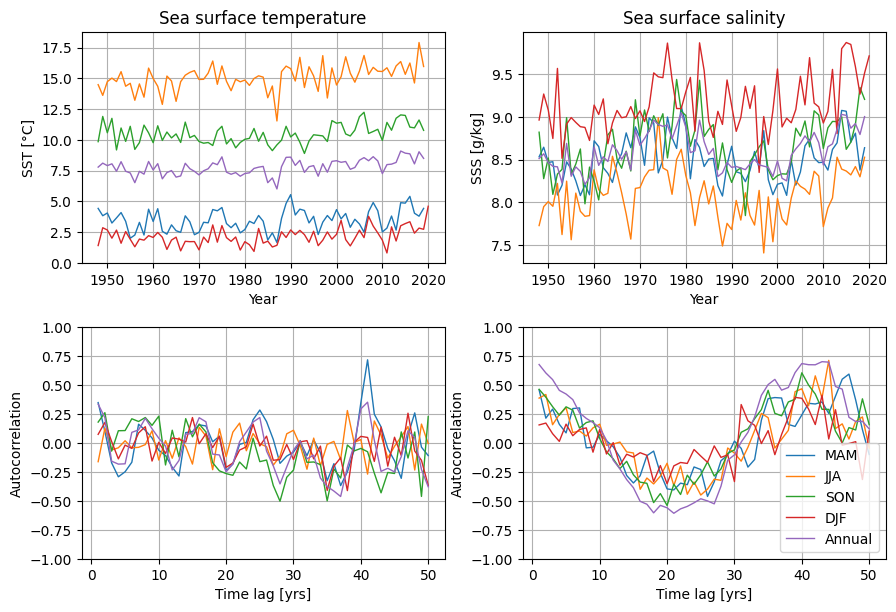

In [ ]:
fig, ax = basicplot_SEASONAL_temp_and_salt(seasonal_SST,seasonal_SSS,autocorr_SST,autocorr_SSS)
ax[0,0].set_title('Sea surface temperature')
ax[0,1].set_title('Sea surface salinity')
ax[0,0].set_ylabel('SST [°C]')
ax[0,1].set_ylabel('SSS [g/kg]')
ax[1,1].legend(loc='lower right');

## SBT & SBS

In [ ]:
# Select sea bottom temperature and salinity and average over BS
ds_SBT = (ds_oceanmonth.isel(zl=-1)['temp'] * area_weights).sum(dim=["xh", "yh"])
ds_SBS = (ds_oceanmonth.isel(zl=-1)['salt'] * area_weights).sum(dim=["xh", "yh"])

# Compute the seasonal averages with function defined in the beginning
seasonal_SBT = compute_seasonal_averages(ds_SBT)
seasonal_SBS = compute_seasonal_averages(ds_SBS)

In [ ]:
# Compute SBT autocorrelation with function defined in the beginning
autocorr_SBT = np.zeros([5,50])
for i in range(5):
    autocorr_SBT[i,:] = autocorrelation(seasonal_SBT.isel(season=i),50)

# Compute SBS autocorrelation with function defined in the beginning
autocorr_SBS = np.zeros([5,50])
for i in range(5):
    autocorr_SBS[i,:] = autocorrelation(seasonal_SBS.isel(season=i),50)

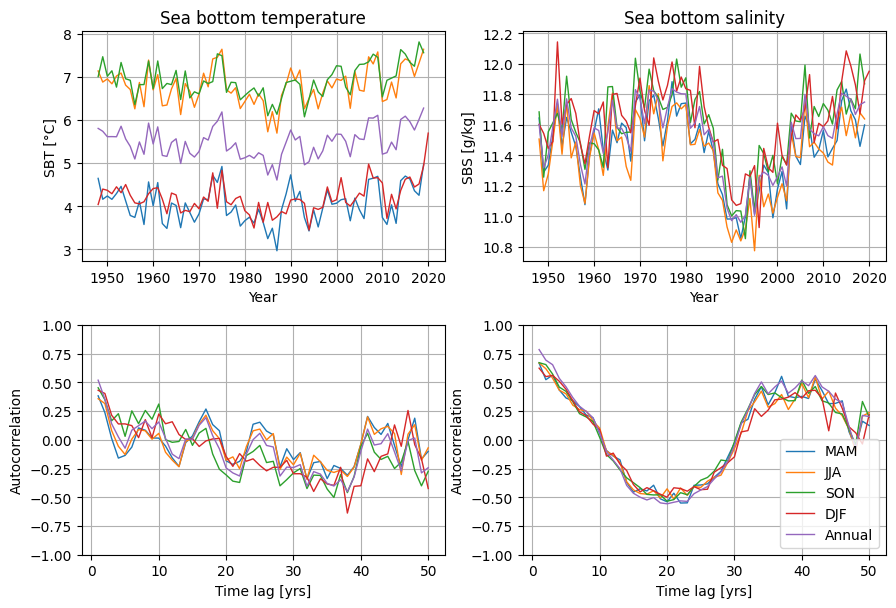

In [ ]:
fig, ax = basicplot_SEASONAL_temp_and_salt(seasonal_SBT,seasonal_SBS,autocorr_SBT,autocorr_SBS)
ax[0,0].set_title('Sea bottom temperature')
ax[0,1].set_title('Sea bottom salinity')
ax[0,0].set_ylabel('SBT [°C]')
ax[0,1].set_ylabel('SBS [g/kg]')
ax[1,1].legend(loc='lower right');

## Total salt & heat

In [23]:
# Read in the annual .nc files containing the results of the reference run
ds_oceanstats = xr.open_mfdataset(
    '../reference_run/reference_run_01_*/ocean.stats.nc',
    combine='nested',  # needed for concat
    concat_dim='Time',  # concatenate along time dimension to get one dataset from 1948-2020
    decode_times=False  # values of time coordinate are weird and will be adapted below
)

# Each year has time values from 01.01.YearX 0:00 to 31.12.YearX 24:00, the latter is equal to 01.01.YearX+1, which is also the first value of the next year. After concatenation the same point in time appears twice in a row.
# The following mask identifies these double entries and removes one of them.

time_values = ds_oceanstats['Time'].values
duplicate_indices = np.where(np.diff(time_values) == 0)[0]  # identify equal consecutive values along the Time coordinate
mask = np.ones(time_values.shape, dtype=bool)  # create a mask with same shape as time coordinates with all values True
mask[duplicate_indices] = False  # sets all double index points to False
ds_oceanstats = ds_oceanstats.isel(Time=mask)  # apply mask to ds to remove double entries
ds_oceanstats = ds_oceanstats.assign_coords(Time=pd.date_range(start="1948-01", end="2020-01", freq="6h"))  # assign correct datetime values to the Time coordinate, the ds contains values each 6h

In [ ]:
# Compute the seasonal averages with function defined in the beginning
seasonal_totalsalt = compute_seasonal_averages(ds_oceanstats['Salt'])
seasonal_totalheat = compute_seasonal_averages(ds_oceanstats['Heat'])

# Compute total salt autocorrelation with function defined in the beginning
autocorr_totalsalt = np.zeros([5,50])
for i in range(5):
    autocorr_totalsalt[i,:] = autocorrelation(seasonal_totalsalt.isel(season=i),50)

# Compute total heat autocorrelation with function defined in the beginning
autocorr_totalheat = np.zeros([5,50])
for i in range(5):
    autocorr_totalheat[i,:] = autocorrelation(seasonal_totalheat.isel(season=i),50)

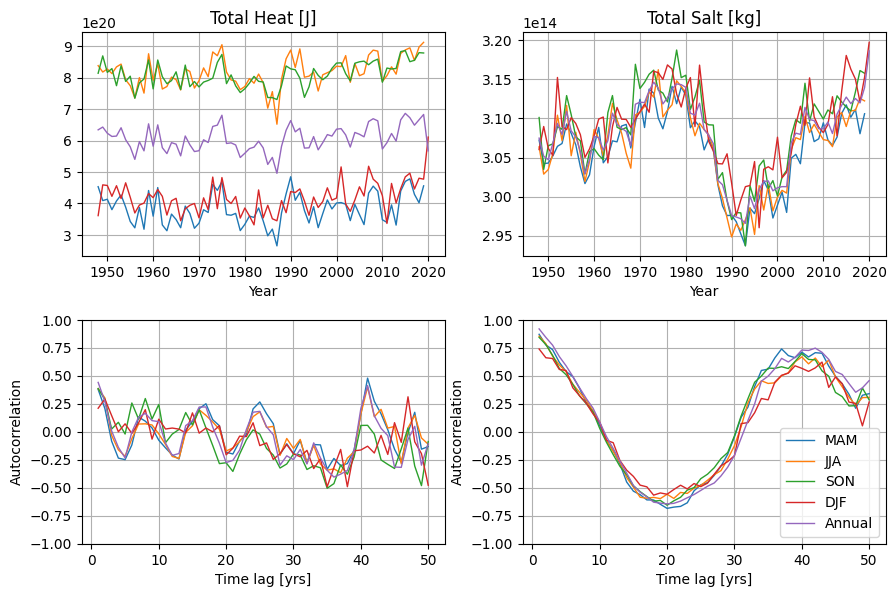

In [ ]:
fig, ax = basicplot_SEASONAL_temp_and_salt(seasonal_totalheat, seasonal_totalsalt, autocorr_totalheat, autocorr_totalsalt)
ax[0,0].set_title('Total Heat [J]')
ax[0,1].set_title('Total Salt [kg]')
ax[1,1].legend(loc='lower right');

## SSH

In [ ]:
# Read in the annual .nc files containing the results of the reference run
ds_sfc = xr.open_mfdataset(
    '../reference_run/reference_run_01_*/*0101.ocean_sfc.nc',
    combine='nested',  # needed for concat
    concat_dim='time',  # concatenate along time dimension to get one dataset from 1948-2020
    decode_times=xr.coding.times.CFDatetimeCoder(use_cftime=True)
)
#ds_sfc['time'] = ds_sfc.indexes['time'].to_datetimeindex()
print(ds_sfc)

<xarray.Dataset> Size: 6GB
Dimensions:  (time: 26298, yh: 102, xh: 91, xq: 92, yq: 103)
Coordinates:
  * xh       (xh) float64 728B 8.12 8.36 8.6 8.84 ... 29.0 29.24 29.48 29.72
  * yh       (yh) float64 816B 53.64 53.76 53.88 54.0 ... 65.4 65.52 65.64 65.76
  * time     (time) object 210kB 1948-01-02 00:00:00 ... 2020-01-01 00:00:00
  * xq       (xq) float64 736B 8.0 8.24 8.48 8.72 ... 29.12 29.36 29.6 29.84
  * yq       (yq) float64 824B 53.58 53.7 53.82 53.94 ... 65.46 65.58 65.7 65.82
Data variables:
    SSH      (time, yh, xh) float32 976MB dask.array<chunksize=(366, 102, 91), meta=np.ndarray>
    SSU      (time, yh, xq) float32 987MB dask.array<chunksize=(366, 102, 92), meta=np.ndarray>
    SSV      (time, yq, xh) float32 986MB dask.array<chunksize=(366, 103, 91), meta=np.ndarray>
    SST      (time, yh, xh) float32 976MB dask.array<chunksize=(366, 102, 91), meta=np.ndarray>
    SSS      (time, yh, xh) float32 976MB dask.array<chunksize=(366, 102, 91), meta=np.ndarray>
    speed 

In [ ]:
ds_SSH = (ds_sfc['SSH'] * area_weights).sum(dim=["xh", "yh"])
#autocorr_SSH = autocorrelation(ds_SSH,1440)
ds_SSH_landsort = ds_sfc.sel(xh=17.87, yh=58.74, method='nearest')['SSH']
#autocorr_SSH_landsort = autocorrelation(ds_SSH_landsort,1440)

/tmp/ipykernel_92376/1330354681.py:2: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'julian', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  ax[0].plot(ds_sfc.indexes['time'].to_datetimeindex(), ds_SSH)#rolling(time=100, center=True).mean(), label='average SSH')
/tmp/ipykernel_92376/1330354681.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()


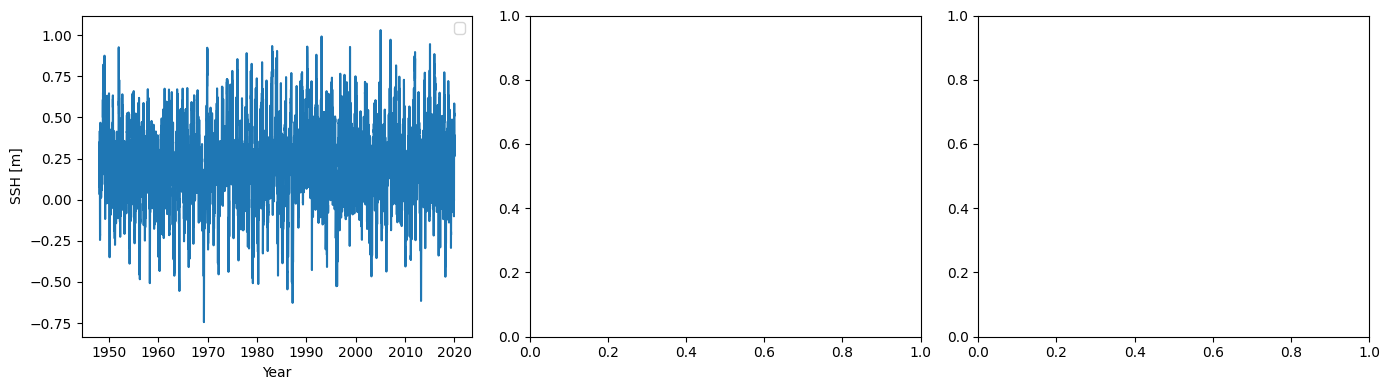

In [ ]:
fig, ax = plt.subplots(1,3, figsize=(14,4))
ax[0].plot(ds_sfc.indexes['time'].to_datetimeindex(), ds_SSH)#rolling(time=100, center=True).mean(), label='average SSH')
#ax[0].plot(ds_SSH_landsort.rolling(time=100, center=True).mean(), label='Landsort SSH')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('SSH [m]')
ax[0].legend()
'''time_lag = np.arange(1,len(autocorr_SSH)+1)
ax[1].plot(time_lag[:100], autocorr_SSH[:100], label='average SSH')
ax[1].plot(time_lag[:100], autocorr_SSH_landsort[:100], label='Landsort SSH')
ax[1].set_xlabel('Time lag [days]')
ax[1].set_ylabel('Autocorrelation')
ax[2].plot(time_lag, autocorr_SSH, label='average SSH')
ax[2].plot(time_lag, autocorr_SSH_landsort, label='Landsort SSH')
ax[2].set_xlabel('Time lag [days]')
ax[2].set_ylabel('Autocorrelation')'''
plt.tight_layout();

## Sea Ice

In [ ]:
# Read in the annual .nc files containing the results of the reference run
ds_ice = xr.open_mfdataset(
    '../reference_run/reference_run_01_*/*0101.ice_month.nc',
    combine='nested',  # needed for concat
    concat_dim='time',  # concatenate along time dimension to get one dataset from 1948-2020
)

ds_ice_n = ds_ice.rename({'xT': 'xh', 'yT': 'yh'})
print(ds_ice_n)

<xarray.Dataset> Size: 1GB
Dimensions:     (time: 864, yT: 102, xT: 91, ct: 5, xB: 92, yB: 103, nv: 2,
                 xTe: 92, yTe: 103)
Coordinates:
  * xT          (xT) float64 728B 8.12 8.36 8.6 8.84 ... 29.0 29.24 29.48 29.72
  * xTe         (xTe) float64 736B 8.0 8.24 8.48 8.72 ... 29.12 29.36 29.6 29.84
  * yT          (yT) float64 816B 53.64 53.76 53.88 54.0 ... 65.52 65.64 65.76
  * yTe         (yTe) float64 824B 53.58 53.7 53.82 53.94 ... 65.58 65.7 65.82
  * time        (time) object 7kB 1948-01-16 12:00:00 ... 2019-12-16 12:00:00
  * nv          (nv) float64 16B 1.0 2.0
  * ct          (ct) float64 40B 1e-10 0.1 0.3 0.7 1.1
  * xB          (xB) float64 736B 8.0 8.24 8.48 8.72 ... 29.12 29.36 29.6 29.84
  * yB          (yB) float64 824B 53.58 53.7 53.82 53.94 ... 65.58 65.7 65.82
Data variables: (12/44)
    FRAZIL      (time, yT, xT) float32 32MB dask.array<chunksize=(12, 102, 91), meta=np.ndarray>
    HI          (time, yT, xT) float32 32MB dask.array<chunksize=(12, 102, 9

In [18]:
ice_EXT = (ds_ice_n['EXT'] * area_weights).sum(dim=["xh", "yh"])
ice_HI = (ds_ice_n['HI'] * area_weights).sum(dim=["xh", "yh"])
ice_CN = (ds_ice_n['CN'] * area_weights).sum(dim=["xh", "yh"])

ice_EXT.to_netcdf("reference_run_time_series/reference_run_ice_EXT.nc")
ice_HI.to_netcdf("reference_run_time_series/reference_run_ice_HI.nc")
ice_CN.to_netcdf("reference_run_time_series/reference_run_ice_CN.nc")

In [ ]:
# Compute volume of ice cover over time + autocorrelation of the time series
ds_ice_h = (ds_ice_n['HI'] * area_weights).sum(dim=["xh","yh"])
#V_ice = (ds_oceanstatic.isel(time=0)['area_t'] * ds_ice_h['HI']).sum(dim=["xh", "yh"])
#V_ice_max = V_ice.resample(time='1YE').max()
#autocorr_V_ice_max = autocorrelation(V_ice_max,60)

In [13]:
# Compute relative ice cover + autocorrelation
ice_cover_rel = (ds_ice_n['EXT'] * area_weights).sum(dim=["xh", "yh"])
#ice_cover_rel_max = ice_cover_rel.resample(time='1YE').max()
#autocorr_ice_cover_max = autocorrelation(ice_cover_rel_max,60)

Pearson correlation between yearly max. ice volume & max. ice cover: 0.93


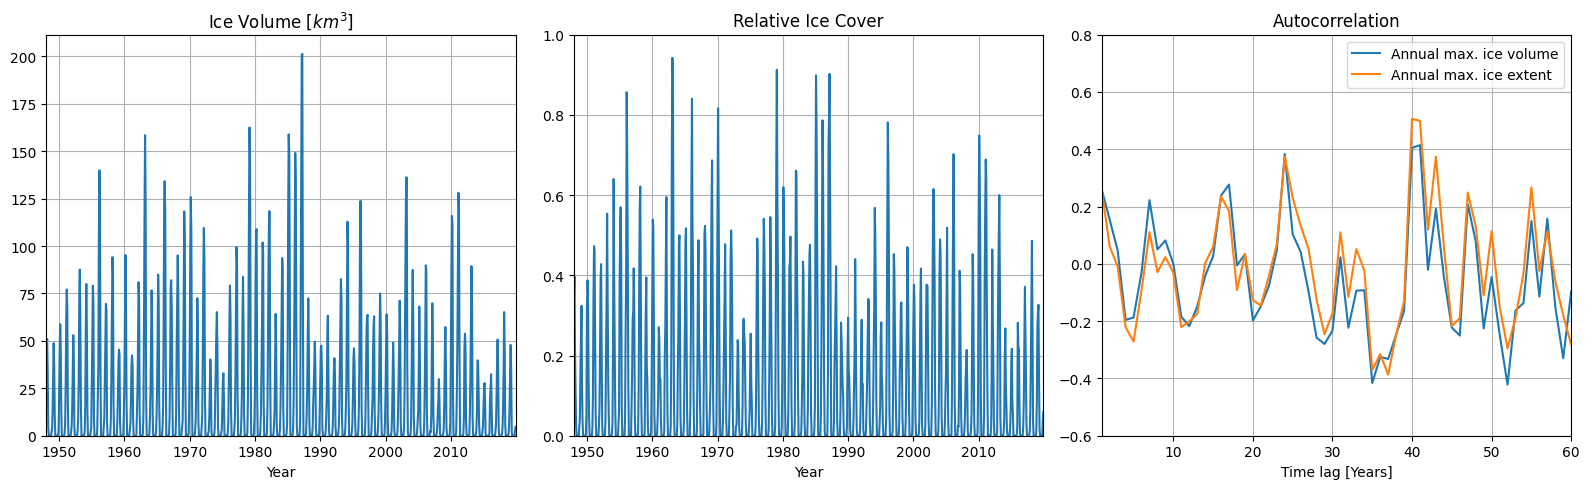

In [ ]:
# Plot
fig, ax = plt.subplots(1,3,figsize=(16,5))
monthly_dates = np.arange(np.datetime64('1948-01','M'), np.datetime64('2020-01','M'), dtype='datetime64[M]')
timelag = np.arange(1,len(autocorr_ice_cover_max)+1,1)
ax[0].plot(monthly_dates, V_ice*10**(-9))
ax[0].set_xlabel('Year')
ax[0].set_title('Ice Volume [$km^3$]')
ax[0].set_xlim(monthly_dates[0], monthly_dates[-1])
ax[0].set_ylim(0)
ax[0].grid()
ax[1].plot(monthly_dates, ice_cover_rel)
ax[1].set_xlabel('Year')
ax[1].set_title('Relative Ice Cover')
ax[1].set_xlim(monthly_dates[0], monthly_dates[-1])
ax[1].set_ylim(0,1)
ax[1].grid()
ax[2].plot(timelag, autocorr_V_ice_max, label='Annual max. ice volume')
ax[2].plot(timelag, autocorr_ice_cover_max, label='Annual max. ice extent')
ax[2].legend(loc='upper right')
ax[2].set_xlabel('Time lag [Years]')
ax[2].set_title('Autocorrelation')
ax[2].set_xlim(timelag[0], timelag[-1])
ax[2].set_ylim(-0.6,0.8)
ax[2].grid()
plt.tight_layout();
print('Pearson correlation between yearly max. ice volume & max. ice cover:', round(np.corrcoef(V_ice_max, ice_cover_rel_max)[0, 1], 2));

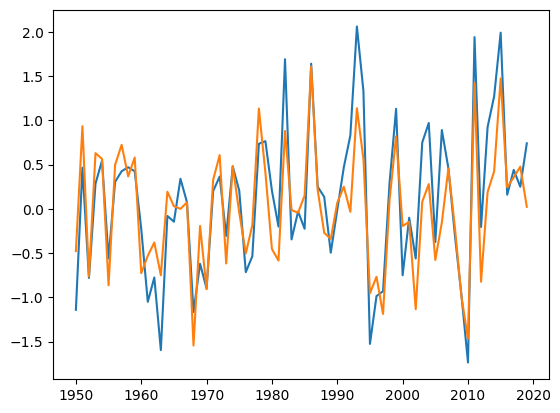

In [ ]:
df = pd.read_csv("NAO_index.txt", sep=r'\s+', header=None)  # read in the file
df.columns = ['year'] + [f'{month:02d}' for month in range(1, 13)]  # name columns
df['JFM_mean'] = df[['01', '02', '03']].astype(float).mean(axis=1)
df['ND_mean'] = df[['11', '12']].astype(float).mean(axis=1)
df['OND_mean'] = df[['10', '11', '12']].astype(float).mean(axis=1)
ds_NAO_JFM = xr.DataArray(data=df['JFM_mean'].values, coords={'time': pd.to_datetime(df['year'], format='%Y')}, dims='time', name='NAO_index').to_dataset()  # transform to wished format: dataset
ds_NAO_ND = xr.DataArray(data=df['ND_mean'].values, coords={'time': pd.to_datetime(df['year'], format='%Y')}, dims='time', name='NAO_index').to_dataset()  # transform to wished format: dataset
ds_NAO_OND = xr.DataArray(data=df['OND_mean'].values, coords={'time': pd.to_datetime(df['year'], format='%Y')}, dims='time', name='NAO_index').to_dataset()  # transform to wished format: dataset
#plt.plot(ds_NAO_JFM.time, ds_NAO_JFM['NAO_index'])
plt.plot(ds_NAO_ND.time, ds_NAO_ND['NAO_index'])
plt.plot(ds_NAO_OND.time, ds_NAO_OND['NAO_index'])

## Plots Vortrag

In [ ]:
labels = ['MAM', 'JJA', 'SON', 'DJF', 'Annual']
linestyles = ['-', '-', '-', '-', '-']
linewidth = [0.5, 0.5, 0.5, 0.5, 0.8]
color = ['C0', 'C1', 'C2', 'C3', 'black']
time_lag = np.arange(1,51)

fig, ax = plt.subplots(1, 3, figsize=(14, 4), sharex=True)

for i in range(5):
    ax[0].plot(time_lag, autocorr_SST[i], label=labels[i], linestyle=linestyles[i], linewidth=linewidth[i], color=color[i])
    ax[1].plot(time_lag, autocorr_SBT[i], label=labels[i], linestyle=linestyles[i], linewidth=linewidth[i], color=color[i])
    ax[2].plot(time_lag, autocorr_totalheat[i], label=labels[i], linestyle=linestyles[i], linewidth=linewidth[i], color=color[i])

for a in ax:
    a.set_ylim(-1, 1)
    a.set_xlim(0, 51)
    a.set_xlabel('Time lag [yrs]', fontsize=14)
    a.grid()
    a.tick_params(axis='both', labelsize=12)

ax[0].set_ylabel('Autocorrelation', fontsize=14)
ax[0].set_title('Sea Surface Temperature', fontsize=16)
ax[1].set_title('Sea Bottom Temperature', fontsize=16)
ax[1].tick_params(left=False, labelleft=False)
ax[2].set_title('Total Heat', fontsize=16)
ax[2].tick_params(left=False, labelleft=False)
fig.legend(labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, 0.02), fontsize=14)
fig.tight_layout(rect=[0, 0.12, 1, 1])

In [ ]:
labels = ['MAM', 'JJA', 'SON', 'DJF', 'Annual']
linestyles = ['-', '-', '-', '-', '-']
linewidth = [0.5, 0.5, 0.5, 0.5, 0.8]
color = ['C0', 'C1', 'C2', 'C3', 'black']
time_lag = np.arange(1,51)

fig, ax = plt.subplots(1, 3, figsize=(14, 4), sharex=True)

for i in range(5):
    ax[0].plot(time_lag, autocorr_SSS[i], label=labels[i], linestyle=linestyles[i], linewidth=linewidth[i], color=color[i])
    ax[1].plot(time_lag, autocorr_SBS[i], label=labels[i], linestyle=linestyles[i], linewidth=linewidth[i], color=color[i])
    ax[2].plot(time_lag, autocorr_totalsalt[i], label=labels[i], linestyle=linestyles[i], linewidth=linewidth[i], color=color[i])

for a in ax:
    a.set_ylim(-1, 1)
    a.set_xlim(0, 51)
    a.set_xlabel('Time lag [yrs]', fontsize=14)
    a.grid()
    a.tick_params(axis='both', labelsize=12)

ax[0].set_ylabel('Autocorrelation', fontsize=14)
ax[0].set_title('Sea Surface Salinity', fontsize=16)
ax[1].set_title('Sea Bottom Salinity', fontsize=16)
ax[1].tick_params(left=False, labelleft=False)
ax[2].set_title('Total Salt', fontsize=16)
ax[2].tick_params(left=False, labelleft=False)
fig.legend(labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, 0.02), fontsize=14)
fig.tight_layout(rect=[0, 0.12, 1, 1])

In [ ]:
plt.figure(figsize=(4,3), dpi=200)
plt.plot(timelag, autocorr_V_ice_max, label='Annual max. ice volume', linewidth=0.8)
plt.plot(timelag, autocorr_ice_cover_max, label='Annual max. ice extent', linewidth=0.8)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.45))
plt.xlabel('Time lag [yrs]')
plt.ylabel('Autocorrelation')
plt.xlim(timelag[0], timelag[-1])
plt.ylim(-0.6,0.8)
plt.grid()
#plt.title('Sea Ice')

In [ ]:
plt.figure(figsize=(4,3), dpi=200)
time_lag = np.arange(1,len(autocorr_SSH)+1)
plt.plot(time_lag[:100], autocorr_SSH[:100], label='average SSH', linewidth=1)
plt.plot(time_lag[:100], autocorr_SSH_landsort[:100], label='Landsort SSH', linewidth=1)
plt.xlabel('Time lag [days]')
plt.ylabel('Autocorrelation')
plt.xlim(time_lag[0], time_lag[99])
plt.grid()
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.45))

## Download Time Series

In [ ]:
ds_oceanstats['Heat'].to_netcdf("reference_run_time_series/reference_run_heat.nc")
ds_oceanstats['Salt'].to_netcdf("reference_run_time_series/reference_run_salt.nc")
#ice_cover_rel.to_netcdf("reference_run_time_series/reference_run_ice.nc")
ds_daily_SSS.to_netcdf("reference_run_time_series/reference_run_SSS.nc")
ds_SSH.to_netcdf("reference_run_time_series/reference_run_SSH.nc")
ds_daily_SST.to_netcdf("reference_run_time_series/reference_run_SST.nc")

## Large Volume Changes

In [ ]:
V_above0 = (ds_sfc['SSH'] * ds_oceanstatic.isel(time=0)['area_t']).sum(dim=["xh", "yh"])
dV = V_above0.diff(dim='time')/(10**9)  # Compute differences between adjacent daily values
std_dV = np.std(dV.values)  # Compute standard deviation
autocorr_dV = autocorrelation(dV,10)
fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].plot(dV['time'], dV.values)
ax[0].set_xlabel('Year')
ax[0].set_title('Daily Volume Change [$km^3$]')
ax[0].set_xlim(dV['time'][0], dV['time'][-1])
ax[0].axhline(-3*std_dV, color='black', alpha=0.3, linestyle='--')
ax[0].axhline(3*std_dV, color='black', alpha=0.3, linestyle='--')
ax[0].fill_between(dV['time'],3*std_dV, -3*std_dV, color='gray', alpha=0.7, label='3x STD')
ax[0].legend()
time_lag = np.arange(1,len(autocorr_dV)+1)
ax[1].plot(time_lag, autocorr_dV)
ax[1].set_xlim(1,len(autocorr_dV))
ax[1].set_xlabel('Time lag [days]')
ax[1].set_title('Autocorrelation');

## MBIs

In [ ]:
# Create mask of Arkona Sea, where we want to detect the inflows

# salt>17 goes up to xh=17.0 and yh=55.8 at some time (I checked)
arkona_mask = (~area_weights.isnull()) & (area_weights.xh < 17) & (area_weights.xh > 12)  & (area_weights.yh < 55.81)
# Finetuning to select the Arkona Basin behind the sills
arkona_mask = arkona_mask.where(~((area_weights.xh < 13) & (area_weights.yh > 55.6)), False)
arkona_mask = arkona_mask.where(~((area_weights.xh < 12.5) & (area_weights.yh < 54.5)), False)
arkona_mask = arkona_mask.where(~((area_weights.xh < 12.4) & (area_weights.yh < 54.7)), False)

# plot of the mask
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
mesh = ax.pcolormesh(arkona_mask.xh.values, arkona_mask.yh.values, arkona_mask.values, transform=ccrs.PlateCarree(), cmap='Blues')
ax.coastlines(resolution='10m')
ax.set_xlim(12, 17)
ax.set_ylim(53.7, 55.81)
gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.5)

In [ ]:
# Apply mask
arkona_salt = ds_oceanmonth['salt'].where(arkona_mask, other=float('nan'))  # applies mask to salt array
arkona_bool_salt17 = arkona_salt > 17  # creates boolean mask

# Get indices a the grid cells
grid_points = np.where(arkona_bool_salt17)  # returns array of 4 arrays of the indices where bool is True
time_indices = np.array(grid_points[0])
zl_indices = np.array(grid_points[1])
yh_indices = np.array(grid_points[2])
xh_indices = np.array(grid_points[3])

# Create arrays for dz and dA
height_array = ds_oceanmonth['h']  # contains the grid cell height as function of (time,zl,yh,xh)
area_array = ds_oceanstatic['area_t'].isel(time=0)  # contains the grid cell area as function of (yh,xh)

# Compute dz and dA arrays
dz = height_array.isel(time=(("points",), time_indices),
            zl=(("points",), zl_indices),
            yh=(("points",), yh_indices),
            xh=(("points",), xh_indices)).values

dA = area_array.isel(yh=(("points",), yh_indices),
            xh=(("points",), xh_indices)).values

# Add all volumes together for each time step
V_salt17 = np.bincount(time_indices, weights=dz*dA)

In [ ]:
autocorr_salt17 = autocorrelation(V_salt17,24)

In [ ]:
# Plot the volume

fig, ax = plt.subplots(1,2,figsize=(12,4))
monthly_dates = np.arange(np.datetime64('1948-01','M'), np.datetime64('2020-01','M'), dtype='datetime64[M]')
ax[0].plot(monthly_dates, V_salt17/10**9)
ax[0].set_ylim(0,2.65*10**2)
ax[0].grid()
ax[0].set_xlabel('Year')
ax[0].set_title('Arkona Basin volume with $S>17$psu [$km^3$]')
ax[1].plot(np.arange(1,25,1), autocorr_salt17)
ax[1].set_xlabel('Time lag [months]')
ax[1].set_title('Autocorrelation')
plt.tight_layout()